In [2]:
import pandas as pd

pd.set_option('display.max_columns', None)

RAW = '../data/raw/'

operaciones = pd.read_excel(RAW + 'operaciones.xlsx')
clientes = pd.read_excel(RAW + 'clientes.xlsx')
trm_usd = pd.read_csv(RAW + 'trm_usd.csv', sep=None, engine='python')
trm_eur = pd.read_excel(RAW + 'trm_eur.xlsx', skiprows=[1])
ciiu_desc = pd.read_excel(RAW + 'ciiu.xlsx')

for nombre, df in [('Operaciones', operaciones), ('Clientes', clientes), 
                    ('TRM USD', trm_usd), ('TRM EUR', trm_eur),
                    ('CIIU desc', ciiu_desc)]:
    print(f"\n--- {nombre} ---")
    print("Shape:", df.shape)
    print(df.dtypes)
    print(df.head(2))


--- Operaciones ---
Shape: (782684, 10)
Fecha              int64
TipoIDC              str
NIT                int64
Producto             str
Lado                 str
Entidad              str
Moneda               str
Monto_Total_     float64
Monto_Entidad    float64
Monto_Mercado    float64
dtype: object
   Fecha TipoIDC  NIT Producto         Lado  Entidad   Moneda  Monto_Total_  \
0  43832      CC  179     SPOT  BANCO VENDE  MERCADO  EUR/COP        1163.8   
1  43832      NT  625     SPOT  BANCO VENDE  MERCADO  USD/COP     2000000.0   

   Monto_Entidad  Monto_Mercado  
0            0.0         1163.8  
1            0.0      2000000.0  

--- Clientes ---
Shape: (10912, 8)
ID             int64
TipoID           str
TipoIDC          str
Segmento         str
Subsegmento      str
Cod_Cartera    int64
CIIU_BUC       int64
IDE              str
dtype: object
   ID TipoID                TipoIDC       Segmento      Subsegmento  \
0   1      P              Pasaporte  Personal Bank  Sin informacio

In [3]:
# 1. Convertir fecha serial de Excel a fecha real
operaciones['Fecha'] = pd.to_timedelta(operaciones['Fecha'], unit='D') + pd.Timestamp('1899-12-30')
print(operaciones['Fecha'].min(), '→', operaciones['Fecha'].max())

# 2. Confirmar el match NIT ↔ ID
print("\n% de NIT con match en ID:", operaciones['NIT'].isin(clientes['ID']).mean() * 100)
print("IDs únicos en Clientes:", clientes['ID'].nunique())
print("IDs duplicados en Clientes:", clientes['ID'].duplicated().sum())

2020-01-02 00:00:00 → 2026-05-29 00:00:00

% de NIT con match en ID: 100.0
IDs únicos en Clientes: 10912
IDs duplicados en Clientes: 0


In [4]:
def parse_numero_es(x):
    """Convierte '$3.427,07' o '2.933,22912' a float 3427.07 / 2933.22912"""
    if pd.isna(x):
        return None
    x = str(x).strip().replace('$', '').replace(' ', '')
    if x in ('', '-', 'nan'):
        return None
    x = x.replace('.', '').replace(',', '.')  # quita puntos de miles, coma -> punto decimal
    return float(x)

# --- TRM USD ---
trm_usd['VALOR'] = trm_usd['VALOR'].apply(parse_numero_es)
trm_usd['VIGENCIADESDE'] = pd.to_datetime(trm_usd['VIGENCIADESDE'], dayfirst=True)
trm_usd['VIGENCIAHASTA'] = pd.to_datetime(trm_usd['VIGENCIAHASTA'], dayfirst=True)

print(trm_usd.head(3))
print(trm_usd.dtypes)

     VALOR UNIDAD VIGENCIADESDE VIGENCIAHASTA
0  3427.07    COP    2026-06-17    2026-06-17
1  3475.72    COP    2026-06-13    2026-06-16
2  3513.54    COP    2026-06-12    2026-06-12
VALOR                   float64
UNIDAD                      str
VIGENCIADESDE    datetime64[us]
VIGENCIAHASTA    datetime64[us]
dtype: object


In [5]:
# --- TRM EUR ---
trm_eur = trm_eur[['Fecha', 'Euro - COP/EUR - Tasa media(Dato diario)']].copy()
trm_eur.columns = ['Fecha', 'TRM_EUR']

trm_eur['Fecha'] = pd.to_datetime(trm_eur['Fecha'], dayfirst=True, errors='coerce')
trm_eur['TRM_EUR'] = trm_eur['TRM_EUR'].apply(parse_numero_es)

print(trm_eur.head(3))
print(trm_eur.dtypes)
print("Filas con fecha inválida:", trm_eur['Fecha'].isna().sum())

       Fecha     TRM_EUR
0 2008-11-20  2933.22912
1 2008-11-21  2951.31629
2 2008-11-22  2946.87542
Fecha      datetime64[us]
TRM_EUR           float64
dtype: object
Filas con fecha inválida: 3


In [6]:
print(trm_eur[trm_eur['Fecha'].isna()])

     Fecha  TRM_EUR
6417   NaT      NaN
6418   NaT      NaN
6419   NaT      NaN


In [7]:
trm_eur = trm_eur.dropna(subset=['Fecha'])
print("Shape final TRM EUR:", trm_eur.shape)

Shape final TRM EUR: (6417, 2)


In [8]:
filas_expandidas = []
for row in trm_usd.itertuples():
    fechas = pd.date_range(row.VIGENCIADESDE, row.VIGENCIAHASTA)
    filas_expandidas.append(pd.DataFrame({'Fecha': fechas, 'TRM_USD': row.VALOR}))

trm_usd_diario = pd.concat(filas_expandidas, ignore_index=True)

print("Shape TRM USD expandido:", trm_usd_diario.shape)
print(trm_usd_diario.head())
print("Rango de fechas:", trm_usd_diario['Fecha'].min(), '→', trm_usd_diario['Fecha'].max())
print("Fechas duplicadas:", trm_usd_diario['Fecha'].duplicated().sum())

Shape TRM USD expandido: (12617, 2)
       Fecha  TRM_USD
0 2026-06-17  3427.07
1 2026-06-13  3475.72
2 2026-06-14  3475.72
3 2026-06-15  3475.72
4 2026-06-16  3475.72
Rango de fechas: 1991-12-02 00:00:00 → 2026-06-17 00:00:00
Fechas duplicadas: 0


In [9]:
# 1. Operaciones + Clientes (por NIT ↔ ID)
df = operaciones.merge(
    clientes.drop(columns=['IDE']),  # la ignoramos, como confirmamos antes
    left_on='NIT', right_on='ID',
    how='left'
)

# 2. + CIIU descripción (por CIIU_BUC ↔ COD_ACT_CIIU_NOCLI)
df = df.merge(
    ciiu_desc,
    left_on='CIIU_BUC', right_on='COD_ACT_CIIU_NOCLI',
    how='left'
)

# 3. + TRM USD (por Fecha)
df = df.merge(trm_usd_diario, on='Fecha', how='left')

# 4. + TRM EUR (por Fecha)
df = df.merge(trm_eur, on='Fecha', how='left')

print("Shape final:", df.shape)
print("\nColumnas:", df.columns.tolist())

# chequeos de calidad
print("\n% sin match de cliente:", df['Segmento'].isna().mean() * 100)
print("% sin match de CIIU desc:", df['DES_CIIU'].isna().mean() * 100)
print("% sin TRM_USD:", df['TRM_USD'].isna().mean() * 100)
print("% sin TRM_EUR:", df['TRM_EUR'].isna().mean() * 100)

Shape final: (782684, 21)

Columnas: ['Fecha', 'TipoIDC_x', 'NIT', 'Producto', 'Lado', 'Entidad', 'Moneda', 'Monto_Total_', 'Monto_Entidad', 'Monto_Mercado', 'ID', 'TipoID', 'TipoIDC_y', 'Segmento', 'Subsegmento', 'Cod_Cartera', 'CIIU_BUC', 'COD_ACT_CIIU_NOCLI', 'DES_CIIU', 'TRM_USD', 'TRM_EUR']

% sin match de cliente: 0.0
% sin match de CIIU desc: 0.6572256491764237
% sin TRM_USD: 0.0
% sin TRM_EUR: 0.0


In [10]:
df['TRM_aplicable'] = df.apply(
    lambda r: r['TRM_USD'] if 'USD' in r['Moneda'] else (r['TRM_EUR'] if 'EUR' in r['Moneda'] else None),
    axis=1
)

print("% de operaciones sin TRM_aplicable:", df['TRM_aplicable'].isna().mean() * 100)
print(df[df['TRM_aplicable'].isna()]['Moneda'].value_counts())

% de operaciones sin TRM_aplicable: 0.91671734697528
Moneda
COP/COP    2366
GBP/COP    1316
CAD/COP    1106
CHF/COP     739
JPY/COP     627
AUD/COP     389
MXN/COP     388
SEK/COP      69
UVR/COP      47
CNH/COP      39
NZD/COP      34
ZAR/COP      31
BRL/COP      12
PEN/COP      12
Name: count, dtype: int64


In [11]:
print(df[df['DES_CIIU'].isna()]['CIIU_BUC'].value_counts())

CIIU_BUC
1032    4715
1031     230
6515     199
Name: count, dtype: int64


In [12]:
# 1. Limpiar columnas duplicadas del merge
df = df.drop(columns=['TipoIDC_y', 'ID', 'COD_ACT_CIIU_NOCLI'])
df = df.rename(columns={'TipoIDC_x': 'TipoIDC'})

# 2. TRM aplicable según moneda de la operación
df['TRM_aplicable'] = df.apply(
    lambda r: r['TRM_USD'] if 'USD' in r['Moneda'] else (r['TRM_EUR'] if 'EUR' in r['Moneda'] else None),
    axis=1
)

print("% de operaciones sin TRM_aplicable:", df['TRM_aplicable'].isna().mean() * 100)
print(df[df['TRM_aplicable'].isna()]['Moneda'].value_counts())

% de operaciones sin TRM_aplicable: 0.91671734697528
Moneda
COP/COP    2366
GBP/COP    1316
CAD/COP    1106
CHF/COP     739
JPY/COP     627
AUD/COP     389
MXN/COP     388
SEK/COP      69
UVR/COP      47
CNH/COP      39
NZD/COP      34
ZAR/COP      31
BRL/COP      12
PEN/COP      12
Name: count, dtype: int64


In [13]:
df.to_parquet('../data/processed/dataset_consolidado.parquet', index=False)
print("Guardado:", df.shape)

Guardado: (782684, 19)


In [14]:
import numpy as np
import pandas as pd

df_sorted = df.sort_values(['NIT', 'Fecha'])

fecha_min = df['Fecha'].min()
fecha_max = df['Fecha'].max()

# Grilla de fechas de corte: un snapshot semanal, dejando 7 días de margen al final
fechas_corte_global = pd.date_range(fecha_min, fecha_max - pd.Timedelta(days=7), freq='W-MON').values
n_fechas = len(fechas_corte_global)

resultados = []

for nit, grupo in df_sorted.groupby('NIT'):
    fechas_ops = grupo['Fecha'].values.astype('datetime64[ns]')
    montos = grupo['Monto_Total_'].values

    idx_hasta_corte = np.searchsorted(fechas_ops, fechas_corte_global, side='right')
    idx_30 = np.searchsorted(fechas_ops, fechas_corte_global - np.timedelta64(30, 'D'), side='right')
    idx_90 = np.searchsorted(fechas_ops, fechas_corte_global - np.timedelta64(90, 'D'), side='right')
    idx_label = np.searchsorted(fechas_ops, fechas_corte_global + np.timedelta64(7, 'D'), side='right')

    # días desde la última operación, al momento del corte
    dias_desde_ultima = np.full(n_fechas, np.nan)
    tiene_historia = idx_hasta_corte > 0
    idx_prev = np.clip(idx_hasta_corte - 1, 0, None)
    ultimas_fechas = fechas_ops[idx_prev]
    dias_desde_ultima[tiene_historia] = (
        (fechas_corte_global[tiene_historia] - ultimas_fechas[tiene_historia]) / np.timedelta64(1, 'D')
    )

    freq_30d = idx_hasta_corte - idx_30
    freq_90d = idx_hasta_corte - idx_90

    cum_montos = np.concatenate([[0], np.cumsum(montos)])
    suma_90 = cum_montos[idx_hasta_corte] - cum_montos[idx_90]
    monto_prom_90d = np.divide(
        suma_90, freq_90d,
        out=np.full(n_fechas, np.nan),
        where=freq_90d > 0
    )

    # label: ¿operó en los 7 días siguientes al corte?
    label = (idx_label > idx_hasta_corte).astype(int)

    resultados.append(pd.DataFrame({
        'NIT': nit,
        'fecha_corte': fechas_corte_global,
        'dias_desde_ultima_op': dias_desde_ultima,
        'freq_30d': freq_30d,
        'freq_90d': freq_90d,
        'monto_prom_90d': monto_prom_90d,
        'label': label
    }))

panel = pd.concat(resultados, ignore_index=True)

print("Shape del panel:", panel.shape)
print("\nBalance del label:")
print(panel['label'].value_counts(normalize=True))
print("\n", panel.head(10))

Shape del panel: (3633696, 7)

Balance del label:
label
0    0.894953
1    0.105047
Name: proportion, dtype: float64

    NIT fecha_corte  dias_desde_ultima_op  freq_30d  freq_90d  monto_prom_90d  \
0    1  2020-01-06                   NaN         0         0             NaN   
1    1  2020-01-13                   NaN         0         0             NaN   
2    1  2020-01-20                   NaN         0         0             NaN   
3    1  2020-01-27                   NaN         0         0             NaN   
4    1  2020-02-03                   NaN         0         0             NaN   
5    1  2020-02-10                   NaN         0         0             NaN   
6    1  2020-02-17                   NaN         0         0             NaN   
7    1  2020-02-24                   NaN         0         0             NaN   
8    1  2020-03-02                   NaN         0         0             NaN   
9    1  2020-03-09                   NaN         0         0             NaN   



In [15]:
print(panel[panel['NIT'] == 1].tail(10))

     NIT fecha_corte  dias_desde_ultima_op  freq_30d  freq_90d  \
323    1  2026-03-16                 682.0         0         0   
324    1  2026-03-23                 689.0         0         0   
325    1  2026-03-30                 696.0         0         0   
326    1  2026-04-06                 703.0         0         0   
327    1  2026-04-13                 710.0         0         0   
328    1  2026-04-20                 717.0         0         0   
329    1  2026-04-27                 724.0         0         0   
330    1  2026-05-04                 731.0         0         0   
331    1  2026-05-11                 738.0         0         0   
332    1  2026-05-18                 745.0         0         0   

     monto_prom_90d  label  
323             NaN      0  
324             NaN      0  
325             NaN      0  
326             NaN      0  
327             NaN      0  
328             NaN      0  
329             NaN      0  
330             NaN      0  
331         

In [16]:
# variables estáticas del cliente — una fila por NIT
clientes_estatico = df[['NIT', 'Segmento', 'Subsegmento', 'CIIU_BUC', 'DES_CIIU']].drop_duplicates(subset='NIT')

panel = panel.merge(clientes_estatico, on='NIT', how='left')

print("Shape final:", panel.shape)
print("% sin match:", panel['Segmento'].isna().mean() * 100)

# variables de calendario, útiles para detectar estacionalidad
panel['dia_mes'] = panel['fecha_corte'].dt.day
panel['mes'] = panel['fecha_corte'].dt.month
panel['semana_año'] = panel['fecha_corte'].dt.isocalendar().week

print(panel.head(3))

Shape final: (3633696, 11)
% sin match: 0.0
   NIT fecha_corte  dias_desde_ultima_op  freq_30d  freq_90d  monto_prom_90d  \
0    1  2020-01-06                   NaN         0         0             NaN   
1    1  2020-01-13                   NaN         0         0             NaN   
2    1  2020-01-20                   NaN         0         0             NaN   

   label       Segmento      Subsegmento  CIIU_BUC  \
0      0  Personal Bank  Sin informacion        10   
1      0  Personal Bank  Sin informacion        10   
2      0  Personal Bank  Sin informacion        10   

                                   DES_CIIU  dia_mes  mes  semana_año  
0  ASALARIADOS: PERSONAS NATURALES Y SUCESI        6    1           2  
1  ASALARIADOS: PERSONAS NATURALES Y SUCESI       13    1           3  
2  ASALARIADOS: PERSONAS NATURALES Y SUCESI       20    1           4  


In [17]:
fecha_corte_train = pd.Timestamp('2025-01-01')

train = panel[panel['fecha_corte'] < fecha_corte_train].copy()
test = panel[panel['fecha_corte'] >= fecha_corte_train].copy()

print("Train:", train.shape, "→", train['fecha_corte'].min(), "a", train['fecha_corte'].max())
print("Test:", test.shape, "→", test['fecha_corte'].min(), "a", test['fecha_corte'].max())
print("\nBalance label train:", train['label'].mean())
print("Balance label test:", test['label'].mean())

Train: (2848032, 14) → 2020-01-06 00:00:00 a 2024-12-30 00:00:00
Test: (785664, 14) → 2025-01-06 00:00:00 a 2026-05-18 00:00:00

Balance label train: 0.10243986022628959
Balance label test: 0.11449932795698925


In [18]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, classification_report

features = ['dias_desde_ultima_op', 'freq_30d', 'freq_90d', 'monto_prom_90d',
            'CIIU_BUC', 'dia_mes', 'mes', 'semana_año']
cat_features = ['CIIU_BUC']

# LightGBM necesita las categóricas como tipo 'category', no int
train['CIIU_BUC'] = train['CIIU_BUC'].astype('category')
test['CIIU_BUC'] = test['CIIU_BUC'].astype('category')

X_train, y_train = train[features], train['label']
X_test, y_test = test[features], test['label']

modelo_timing = lgb.LGBMClassifier(
    objective='binary',
    is_unbalance=True,
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

modelo_timing.fit(
    X_train, y_train,
    categorical_feature=cat_features
)

# evaluación
proba_test = modelo_timing.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= 0.5).astype(int)

print("AUC:", roc_auc_score(y_test, proba_test))
print("\n", classification_report(y_test, pred_test))

# importancia de features
importancias = pd.Series(modelo_timing.feature_importances_, index=features).sort_values(ascending=False)
print("\nImportancia de variables:\n", importancias)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 291752, number of negative: 2556280
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.099043 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1239
[LightGBM] [Info] Number of data points in the train set: 2848032, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.102440 -> initscore=-2.170404
[LightGBM] [Info] Start training from score -2.170404
AUC: 0.9232117745902215

               precision    recall  f1-score   support

           0       0.98      0.83      0.90    695706
           1       0.40      0.87      0.54     89958

    accuracy     

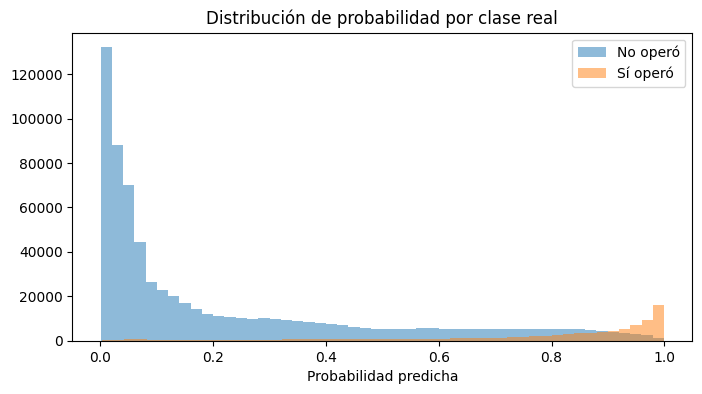

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(proba_test[y_test==0], bins=50, alpha=0.5, label='No operó')
plt.hist(proba_test[y_test==1], bins=50, alpha=0.5, label='Sí operó')
plt.legend()
plt.xlabel('Probabilidad predicha')
plt.title('Distribución de probabilidad por clase real')
plt.show()

In [20]:
modelo_timing_gain = lgb.LGBMClassifier(
    objective='binary', is_unbalance=True,
    n_estimators=300, learning_rate=0.05, random_state=42,
    importance_type='gain'
)
modelo_timing_gain.fit(X_train, y_train, categorical_feature=cat_features)

importancias_gain = pd.Series(
    modelo_timing_gain.feature_importances_, index=features
).sort_values(ascending=False)
print(importancias_gain)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 291752, number of negative: 2556280
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.101676 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1239
[LightGBM] [Info] Number of data points in the train set: 2848032, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.102440 -> initscore=-2.170404
[LightGBM] [Info] Start training from score -2.170404
freq_90d                1.674364e+07
dias_desde_ultima_op    1.276812e+07
CIIU_BUC                1.681472e+06
freq_30d                4.443327e+05
dia_mes                 2.878743e+05
semana_año            

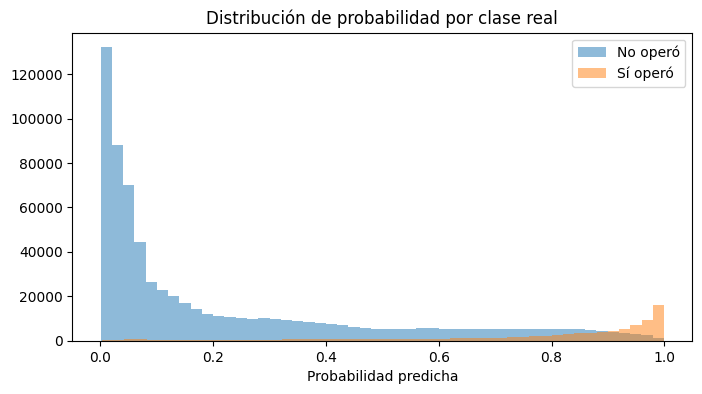

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(proba_test[y_test==0], bins=50, alpha=0.5, label='No operó')
plt.hist(proba_test[y_test==1], bins=50, alpha=0.5, label='Sí operó')
plt.legend()
plt.xlabel('Probabilidad predicha')
plt.title('Distribución de probabilidad por clase real')
plt.show()

In [22]:
# Celda 1: Reentrenar con más features
features_v2 = ['dias_desde_ultima_op', 'freq_30d', 'freq_90d', 'monto_prom_90d',
                'CIIU_BUC', 'Segmento', 'Subsegmento', 'dia_mes', 'mes', 'semana_año']
cat_features_v2 = ['CIIU_BUC', 'Segmento', 'Subsegmento']

for col in cat_features_v2:
    train[col] = train[col].astype('category')
    test[col] = test[col].astype('category')

X_train_v2 = train[features_v2]
X_test_v2  = test[features_v2]

modelo_v2 = lgb.LGBMClassifier(
    objective='binary',
    is_unbalance=True,
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

modelo_v2.fit(X_train_v2, y_train, categorical_feature=cat_features_v2)

proba_v2 = modelo_v2.predict_proba(X_test_v2)[:, 1]

print("AUC v1:", roc_auc_score(y_test, proba_test))
print("AUC v2:", roc_auc_score(y_test, proba_v2))

importancias_v2 = pd.Series(
    modelo_v2.feature_importances_, index=features_v2
).sort_values(ascending=False)
print("\nImportancia v2:\n", importancias_v2)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 291752, number of negative: 2556280
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.111214 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1270
[LightGBM] [Info] Number of data points in the train set: 2848032, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.102440 -> initscore=-2.170404
[LightGBM] [Info] Start training from score -2.170404
AUC v1: 0.9232117745902215
AUC v2: 0.9242502040345077

Importancia v2:
 CIIU_BUC                5057
dias_desde_ultima_op    1018
dia_mes                  706
semana_año               624
freq_90d          

Umbral óptimo (F2): 0.577
  Precision en ese umbral: 0.437
  Recall en ese umbral:    0.835


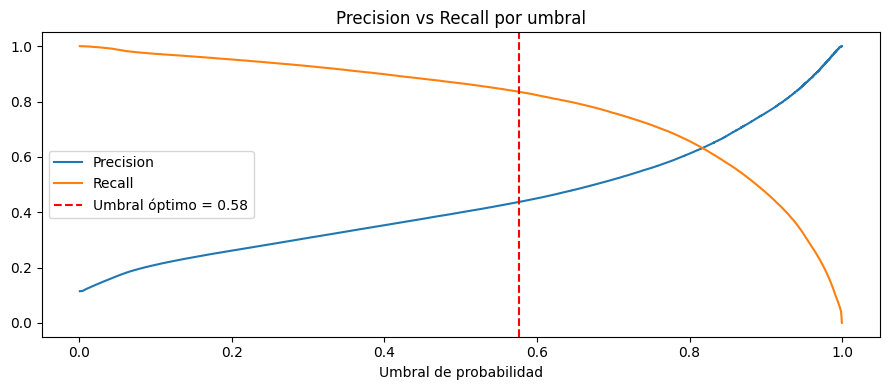

In [23]:
# Celda 2: Curva precision-recall y umbral óptimo
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Usar proba_v2 si el AUC mejoró, sino proba_test
proba_final = proba_v2  # cambia a proba_test si v2 no mejoró

precisions, recalls, thresholds = precision_recall_curve(y_test, proba_final)

# F-beta con beta=2: pondera recall el doble que precision
beta = 2
fbeta = (1 + beta**2) * (precisions * recalls) / (beta**2 * precisions + recalls + 1e-9)
idx_mejor = fbeta[:-1].argmax()
umbral_optimo = thresholds[idx_mejor]

print(f"Umbral óptimo (F2): {umbral_optimo:.3f}")
print(f"  Precision en ese umbral: {precisions[idx_mejor]:.3f}")
print(f"  Recall en ese umbral:    {recalls[idx_mejor]:.3f}")

# Gráfica
plt.figure(figsize=(9, 4))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.axvline(umbral_optimo, color='red', linestyle='--', label=f'Umbral óptimo = {umbral_optimo:.2f}')
plt.xlabel('Umbral de probabilidad')
plt.title('Precision vs Recall por umbral')
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
# Celda 3: Ranking para la semana más reciente del test
ultima_semana = test['fecha_corte'].max()
mask = test['fecha_corte'] == ultima_semana

ranking = test[mask][['NIT', 'fecha_corte', 'Segmento', 'Subsegmento']].copy()
ranking['prob_operar'] = proba_final[mask.values]
ranking = ranking.sort_values('prob_operar', ascending=False)
ranking['alerta'] = (ranking['prob_operar'] >= umbral_optimo).map({True: '🔴 Llamar', False: '⚪ Esperar'})

print(f"Semana: {ultima_semana.date()}")
print(f"Clientes a llamar: {(ranking['alerta'] == '🔴 Llamar').sum()} de {len(ranking)}")
print()
print(ranking.head(20).to_string(index=False))

Semana: 2026-05-18
Clientes a llamar: 2408 de 10912

  NIT fecha_corte         Segmento                   Subsegmento  prob_operar   alerta
 1244  2026-05-18              CIB Mesa Centralizada Corporativo     0.999382 🔴 Llamar
 2331  2026-05-18              CIB                   Corporativo     0.999378 🔴 Llamar
 4081  2026-05-18              CIB                   Corporativo     0.999374 🔴 Llamar
 1534  2026-05-18              CIB Mesa Centralizada Corporativo     0.999373 🔴 Llamar
 6680  2026-05-18              CIB Mesa Centralizada Corporativo     0.999335 🔴 Llamar
 8135  2026-05-18              CIB Mesa Centralizada Corporativo     0.999320 🔴 Llamar
 1212  2026-05-18              CIB                   Corporativo     0.999308 🔴 Llamar
 9878  2026-05-18              CIB Mesa Centralizada Corporativo     0.999305 🔴 Llamar
 8980  2026-05-18            Pymes            Mesa Atencion Pyme     0.999292 🔴 Llamar
 7285  2026-05-18              CIB Mesa Centralizada Corporativo     0.999274

In [25]:
# Celda 4: Guardar modelo y artefactos
import pickle, json, os

os.makedirs('../models', exist_ok=True)

# Guardar modelo
with open('../models/modelo_timing_v2.pkl', 'wb') as f:
    pickle.dump(modelo_v2, f)

# Guardar umbral y metadata
metadata = {
    'umbral': float(umbral_optimo),
    'auc_test': float(roc_auc_score(y_test, proba_v2)),
    'features': features_v2,
    'cat_features': cat_features_v2,
    'fecha_corte_train': '2025-01-01',
    'recall_en_umbral': float(recalls[idx_mejor]),
    'precision_en_umbral': float(precisions[idx_mejor]),
}

with open('../models/modelo_timing_v2_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Guardado:")
print(f"  modelo   → ../models/modelo_timing_v2.pkl")
print(f"  metadata → ../models/modelo_timing_v2_metadata.json")
print(json.dumps(metadata, indent=2))

Guardado:
  modelo   → ../models/modelo_timing_v2.pkl
  metadata → ../models/modelo_timing_v2_metadata.json
{
  "umbral": 0.5768263212587227,
  "auc_test": 0.9242502040345077,
  "features": [
    "dias_desde_ultima_op",
    "freq_30d",
    "freq_90d",
    "monto_prom_90d",
    "CIIU_BUC",
    "Segmento",
    "Subsegmento",
    "dia_mes",
    "mes",
    "semana_a\u00f1o"
  ],
  "cat_features": [
    "CIIU_BUC",
    "Segmento",
    "Subsegmento"
  ],
  "fecha_corte_train": "2025-01-01",
  "recall_en_umbral": 0.8350674759332133,
  "precision_en_umbral": 0.43743157943772853
}


In [26]:
print(df['Producto'].value_counts())
print("\nTotal productos únicos:", df['Producto'].nunique())

Producto
SPOT        368620
FORWARD     292692
NEXT DAY     64816
FIX          29468
OPCIONES     23286
SWAPS         3802
Name: count, dtype: int64

Total productos únicos: 6


In [27]:
# Celda 1: Panel modelo de producto (multiclase 5 categorías)
ops = df[['NIT', 'Fecha', 'Producto']].sort_values(['NIT', 'Fecha'])

# Agrupar productos minoritarios
def agrupar_producto(p):
    if p in ('OPCIONES', 'SWAPS'):
        return 'OTROS'
    return p

ops['Producto_grupo'] = ops['Producto'].apply(agrupar_producto)

# Solo filas del panel donde el cliente operó (label == 1)
panel_pos = panel[panel['label'] == 1].copy().sort_values(['NIT', 'fecha_corte'])

resultados_producto = []

print("Construyendo target... (puede tardar 2-3 min)")

for nit, grp_panel in panel_pos.groupby('NIT'):
    grp_ops = ops[ops['NIT'] == nit]
    for _, row in grp_panel.iterrows():
        ops_ventana = grp_ops[
            (grp_ops['Fecha'] > row['fecha_corte']) &
            (grp_ops['Fecha'] <= row['fecha_corte'] + pd.Timedelta(days=7))
        ]
        prod = ops_ventana.iloc[0]['Producto_grupo'] if len(ops_ventana) > 0 else None
        resultados_producto.append(prod)

panel_pos['producto_siguiente'] = resultados_producto
panel_producto = panel_pos[panel_pos['producto_siguiente'].notna()].copy()

print("Shape panel producto:", panel_producto.shape)
print("\nDistribución target:")
print(panel_producto['producto_siguiente'].value_counts())
print("\n%:")
print(panel_producto['producto_siguiente'].value_counts(normalize=True).round(3))

Construyendo target... (puede tardar 2-3 min)
Shape panel producto: (381710, 15)

Distribución target:
producto_siguiente
SPOT        203950
FORWARD     122817
NEXT DAY     34669
FIX          13133
OTROS         7141
Name: count, dtype: int64

%:
producto_siguiente
SPOT        0.534
FORWARD     0.322
NEXT DAY    0.091
FIX         0.034
OTROS       0.019
Name: proportion, dtype: float64


In [30]:
# Celda 2 (versión memory-safe): Historial por lotes
from tqdm.notebook import tqdm  # barra de progreso, opcional

ops_hist = df[['NIT', 'Fecha', 'Producto']].copy()
ops_hist['Producto_grupo'] = ops_hist['Producto'].apply(agrupar_producto)

productos = ['SPOT', 'FORWARD', 'NEXT DAY', 'FIX', 'OTROS']
hist_cols = [f'hist_90d_{p}' for p in productos]

# Inicializar columnas
for col in hist_cols:
    panel_producto[col] = 0

nits = panel_producto['NIT'].unique()
print(f"Procesando {len(nits)} clientes...")

ops_by_nit = ops_hist.groupby('NIT')

for i, nit in enumerate(nits):
    if i % 500 == 0:
        print(f"  {i}/{len(nits)}")
    
    if nit not in ops_by_nit.groups:
        continue
    
    grp_ops = ops_by_nit.get_group(nit)
    mask_nit = panel_producto['NIT'] == nit
    fechas_corte = panel_producto.loc[mask_nit, 'fecha_corte']
    
    for prod in productos:
        ops_prod = grp_ops[grp_ops['Producto_grupo'] == prod]['Fecha'].values
        
        counts = np.array([
            ((ops_prod > (fc - pd.Timedelta(days=90))) & (ops_prod <= fc)).sum()
            for fc in fechas_corte
        ])
        
        panel_producto.loc[mask_nit, f'hist_90d_{prod}'] = counts

print("Listo")
print(panel_producto[['NIT', 'fecha_corte', 'producto_siguiente'] + hist_cols].head(8))

Procesando 10880 clientes...
  0/10880
  500/10880
  1000/10880
  1500/10880
  2000/10880
  2500/10880
  3000/10880
  3500/10880
  4000/10880
  4500/10880
  5000/10880
  5500/10880
  6000/10880
  6500/10880
  7000/10880
  7500/10880
  8000/10880
  8500/10880
  9000/10880
  9500/10880
  10000/10880
  10500/10880
Listo
   NIT fecha_corte producto_siguiente  hist_90d_SPOT  hist_90d_FORWARD  \
0    1  2021-06-28           NEXT DAY              0                 0   
1    1  2022-01-31           NEXT DAY              0                 0   
2    1  2022-03-07           NEXT DAY              0                 0   
3    1  2023-01-30           NEXT DAY              0                 0   
4    1  2023-03-13           NEXT DAY              0                 0   
5    1  2024-02-12           NEXT DAY              0                 0   
6    1  2024-04-29           NEXT DAY              0                 0   
7    2  2025-09-29               SPOT              0                 0   

   hist_90d_NE

In [31]:
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import lightgbm as lgb

features_prod = ['dias_desde_ultima_op', 'freq_30d', 'freq_90d', 'monto_prom_90d',
                 'CIIU_BUC', 'Segmento', 'Subsegmento', 'dia_mes', 'mes', 'semana_año',
                 'hist_90d_SPOT', 'hist_90d_FORWARD', 'hist_90d_NEXT DAY',
                 'hist_90d_FIX', 'hist_90d_OTROS']
cat_features_prod = ['CIIU_BUC', 'Segmento', 'Subsegmento']

le = LabelEncoder()
panel_producto['label_prod'] = le.fit_transform(panel_producto['producto_siguiente'])

fecha_corte_train = pd.Timestamp('2025-01-01')
train_p = panel_producto[panel_producto['fecha_corte'] < fecha_corte_train].copy()
test_p  = panel_producto[panel_producto['fecha_corte'] >= fecha_corte_train].copy()

for col in cat_features_prod:
    train_p[col] = train_p[col].astype('category')
    test_p[col]  = test_p[col].astype('category')

modelo_producto = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=5,
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

modelo_producto.fit(train_p[features_prod], train_p['label_prod'],
                    categorical_feature=cat_features_prod)

proba_prod = modelo_producto.predict_proba(test_p[features_prod])
pred_prod  = proba_prod.argmax(axis=1)

print("Clases:", le.classes_)
print("\n", classification_report(test_p['label_prod'], pred_prod,
                                   target_names=le.classes_))

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013806 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1857
[LightGBM] [Info] Number of data points in the train set: 291752, number of used features: 15
[LightGBM] [Info] Start training from score -3.369825
[LightGBM] [Info] Start training from score -1.133738
[LightGBM] [Info] Start training from score -2.373349
[LightGBM] [Info] Start training from score -3.998808
[LightGBM] [Info] Start training from score -0.630603
Clases: ['FIX' 'FORWARD' 'NEXT DAY' 'OTROS' 'SPOT']

            

In [33]:
# Celda 2 (versión memory-safe): Historial por lotes
from tqdm.notebook import tqdm  # barra de progreso, opcional

ops_hist = df[['NIT', 'Fecha', 'Producto']].copy()
ops_hist['Producto_grupo'] = ops_hist['Producto'].apply(agrupar_producto)

productos = ['SPOT', 'FORWARD', 'NEXT DAY', 'FIX', 'OTROS']
hist_cols = [f'hist_90d_{p}' for p in productos]

# Inicializar columnas
for col in hist_cols:
    panel_producto[col] = 0

nits = panel_producto['NIT'].unique()
print(f"Procesando {len(nits)} clientes...")

ops_by_nit = ops_hist.groupby('NIT')

for i, nit in enumerate(nits):
    if i % 500 == 0:
        print(f"  {i}/{len(nits)}")
    
    if nit not in ops_by_nit.groups:
        continue
    
    grp_ops = ops_by_nit.get_group(nit)
    mask_nit = panel_producto['NIT'] == nit
    fechas_corte = panel_producto.loc[mask_nit, 'fecha_corte']
    
    for prod in productos:
        ops_prod = grp_ops[grp_ops['Producto_grupo'] == prod]['Fecha'].values
        
        counts = np.array([
            ((ops_prod > (fc - pd.Timedelta(days=90))) & (ops_prod <= fc)).sum()
            for fc in fechas_corte
        ])
        
        panel_producto.loc[mask_nit, f'hist_90d_{prod}'] = counts

print("Listo")
print(panel_producto[['NIT', 'fecha_corte', 'producto_siguiente'] + hist_cols].head(8))

Procesando 10880 clientes...
  0/10880
  500/10880
  1000/10880
  1500/10880
  2000/10880
  2500/10880
  3000/10880
  3500/10880
  4000/10880
  4500/10880
  5000/10880
  5500/10880
  6000/10880
  6500/10880
  7000/10880
  7500/10880
  8000/10880
  8500/10880
  9000/10880
  9500/10880
  10000/10880
  10500/10880
Listo
   NIT fecha_corte producto_siguiente  hist_90d_SPOT  hist_90d_FORWARD  \
0    1  2021-06-28           NEXT DAY              0                 0   
1    1  2022-01-31           NEXT DAY              0                 0   
2    1  2022-03-07           NEXT DAY              0                 0   
3    1  2023-01-30           NEXT DAY              0                 0   
4    1  2023-03-13           NEXT DAY              0                 0   
5    1  2024-02-12           NEXT DAY              0                 0   
6    1  2024-04-29           NEXT DAY              0                 0   
7    2  2025-09-29               SPOT              0                 0   

   hist_90d_NE

In [34]:
# Celda 3 — Entrenar modelo de producto
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import lightgbm as lgb

features_prod = ['dias_desde_ultima_op', 'freq_30d', 'freq_90d', 'monto_prom_90d',
                 'CIIU_BUC', 'Segmento', 'Subsegmento', 'dia_mes', 'mes', 'semana_año',
                 'hist_90d_SPOT', 'hist_90d_FORWARD', 'hist_90d_NEXT DAY',
                 'hist_90d_FIX', 'hist_90d_OTROS']
cat_features_prod = ['CIIU_BUC', 'Segmento', 'Subsegmento']

le = LabelEncoder()
panel_producto['label_prod'] = le.fit_transform(panel_producto['producto_siguiente'])

fecha_corte_train = pd.Timestamp('2025-01-01')
train_p = panel_producto[panel_producto['fecha_corte'] < fecha_corte_train].copy()
test_p  = panel_producto[panel_producto['fecha_corte'] >= fecha_corte_train].copy()

for col in cat_features_prod:
    train_p[col] = train_p[col].astype('category')
    test_p[col]  = test_p[col].astype('category')

print("Train:", train_p.shape, "| Test:", test_p.shape)
print("Clases:", le.classes_)
print("\nBalance train:")
print(train_p['producto_siguiente'].value_counts(normalize=True).round(3))

modelo_producto = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=5,
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

modelo_producto.fit(train_p[features_prod], train_p['label_prod'],
                    categorical_feature=cat_features_prod)

proba_prod = modelo_producto.predict_proba(test_p[features_prod])
pred_prod  = proba_prod.argmax(axis=1)

print("\nClasification report:")
print(classification_report(test_p['label_prod'], pred_prod, target_names=le.classes_))

importancias_prod = pd.Series(
    modelo_producto.feature_importances_, index=features_prod
).sort_values(ascending=False)
print("Importancia de variables:\n", importancias_prod)

Train: (291752, 21) | Test: (89958, 21)
Clases: ['FIX' 'FORWARD' 'NEXT DAY' 'OTROS' 'SPOT']

Balance train:
producto_siguiente
SPOT        0.532
FORWARD     0.322
NEXT DAY    0.093
FIX         0.034
OTROS       0.018
Name: proportion, dtype: float64
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.056853 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1857
[LightGBM] [Info] Number of data points in the train set: 291752, number of used features: 15
[LightGBM] [Info] Start training from score -3.369825
[LightGBM] [Info] Start trainin

In [35]:
# Celda 5 — Guardar modelo de producto
import pickle, json

with open('../models/modelo_producto_v1.pkl', 'wb') as f:
    pickle.dump(modelo_producto, f)

with open('../models/label_encoder_producto.pkl', 'wb') as f:
    pickle.dump(le, f)

metadata_prod = {
    'clases': list(le.classes_),
    'features': features_prod,
    'cat_features': cat_features_prod,
    'fecha_corte_train': '2025-01-01',
}
with open('../models/modelo_producto_v1_metadata.json', 'w') as f:
    json.dump(metadata_prod, f, indent=2)

print("Guardado.")


Guardado.


In [37]:
# Validación completa de ambos modelos
import pickle, json
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, classification_report

print("=" * 50)
print("MODELO 1: TIMING (¿va a operar?)")
print("=" * 50)

# Cargar desde disco para confirmar que el pkl está bien
with open('../models/modelo_timing_v2.pkl', 'rb') as f:
    modelo_timing_cargado = pickle.load(f)

with open('../models/modelo_timing_v2_metadata.json') as f:
    meta_timing = json.load(f)

# Predecir con el modelo cargado (no el que está en memoria)
X_test_timing = test[meta_timing['features']].copy()
for col in meta_timing['cat_features']:
    X_test_timing[col] = X_test_timing[col].astype('category')

proba_cargado = modelo_timing_cargado.predict_proba(X_test_timing)[:, 1]
auc_cargado   = roc_auc_score(y_test, proba_cargado)
pred_cargado  = (proba_cargado >= meta_timing['umbral']).astype(int)

print(f"AUC (desde disco):      {auc_cargado:.4f}  ✅" if abs(auc_cargado - meta_timing['auc_test']) < 0.001 else f"AUC (desde disco): {auc_cargado:.4f}  ⚠️ difiere del guardado")
print(f"AUC (metadata guardada): {meta_timing['auc_test']:.4f}")
print(f"Umbral:                  {meta_timing['umbral']:.4f}")
print(f"Recall clase positiva:   {meta_timing['recall_en_umbral']:.4f}")
print(f"Precision clase positiva:{meta_timing['precision_en_umbral']:.4f}")
print(f"Features:                {len(meta_timing['features'])} variables")
print(f"Clientes llamar/semana:  ~2,400 de 10,912")

print()
print("=" * 50)
print("MODELO 2: PRODUCTO (¿qué va a comprar?)")
print("=" * 50)

with open('../models/modelo_producto_v1.pkl', 'rb') as f:
    modelo_producto_cargado = pickle.load(f)

with open('../models/label_encoder_producto.pkl', 'rb') as f:
    le_cargado = pickle.load(f)

with open('../models/modelo_producto_v1_metadata.json') as f:
    meta_prod = json.load(f)

X_test_prod = test_p[meta_prod['features']].copy()
for col in meta_prod['cat_features']:
    X_test_prod[col] = X_test_prod[col].astype('category')

pred_prod_cargado = modelo_producto_cargado.predict(X_test_prod)
proba_prod_cargado = modelo_producto_cargado.predict_proba(X_test_prod)

print(f"Clases: {list(le_cargado.classes_)}")
print(f"Features: {len(meta_prod['features'])} variables")
print()
print(classification_report(
    test_p['label_prod'], pred_prod_cargado,
    target_names=le_cargado.classes_
))

# Chequeo extra: distribución de predicciones (no debe estar colapsada en una sola clase)
pred_labels = le_cargado.inverse_transform(pred_prod_cargado)
print("Distribución de predicciones en test:")
print(pd.Series(pred_labels).value_counts(normalize=True).round(3))

MODELO 1: TIMING (¿va a operar?)
AUC (desde disco):      0.9243  ✅
AUC (metadata guardada): 0.9243
Umbral:                  0.5768
Recall clase positiva:   0.8351
Precision clase positiva:0.4374
Features:                10 variables
Clientes llamar/semana:  ~2,400 de 10,912

MODELO 2: PRODUCTO (¿qué va a comprar?)
Clases: ['FIX', 'FORWARD', 'NEXT DAY', 'OTROS', 'SPOT']
Features: 15 variables

              precision    recall  f1-score   support

         FIX       0.69      0.59      0.63      3098
     FORWARD       0.81      0.85      0.83     28923
    NEXT DAY       0.68      0.38      0.49      7487
       OTROS       0.65      0.31      0.42      1791
        SPOT       0.83      0.89      0.86     48659

    accuracy                           0.81     89958
   macro avg       0.73      0.60      0.65     89958
weighted avg       0.80      0.81      0.80     89958

Distribución de predicciones en test:
SPOT        0.575
FORWARD     0.339
NEXT DAY    0.047
FIX         0.029
OTROS

In [38]:
# Paso 1: Verificar que trm_usd_diario sigue en memoria
print(trm_usd_diario.head(3))
print("Rango:", trm_usd_diario['Fecha'].min(), "→", trm_usd_diario['Fecha'].max())

       Fecha  TRM_USD
0 2026-06-17  3427.07
1 2026-06-13  3475.72
2 2026-06-14  3475.72
Rango: 1991-12-02 00:00:00 → 2026-06-17 00:00:00


In [39]:
# Paso 2: Agregar TRM_USD y variacion_trm_7d al panel
trm_usd_diario = trm_usd_diario.sort_values('Fecha').copy()
trm_usd_diario['variacion_trm_7d'] = trm_usd_diario['TRM_USD'].pct_change(periods=7).round(6)

# Merge al panel por fecha_corte
panel = panel.merge(trm_usd_diario[['Fecha', 'TRM_USD', 'variacion_trm_7d']],
                    left_on='fecha_corte', right_on='Fecha', how='left').drop(columns='Fecha')

print("Nulos TRM_USD:", panel['TRM_USD'].isna().sum())
print("Nulos variacion_trm_7d:", panel['variacion_trm_7d'].isna().sum())
print(panel[['fecha_corte', 'TRM_USD', 'variacion_trm_7d']].head(5))

Nulos TRM_USD: 0
Nulos variacion_trm_7d: 0
  fecha_corte  TRM_USD  variacion_trm_7d
0  2020-01-06  3262.05         -0.009714
1  2020-01-13  3272.62          0.003240
2  2020-01-20  3320.77          0.014713
3  2020-01-27  3366.01          0.013623
4  2020-02-03  3423.24          0.017002


In [40]:
# Paso 3: Reentrenar modelo timing con TRM
features_v3 = ['dias_desde_ultima_op', 'freq_30d', 'freq_90d', 'monto_prom_90d',
                'CIIU_BUC', 'Segmento', 'Subsegmento', 'dia_mes', 'mes', 'semana_año',
                'TRM_USD', 'variacion_trm_7d']
cat_features_v3 = ['CIIU_BUC', 'Segmento', 'Subsegmento']

fecha_corte_train = pd.Timestamp('2025-01-01')
train = panel[panel['fecha_corte'] < fecha_corte_train].copy()
test  = panel[panel['fecha_corte'] >= fecha_corte_train].copy()

for col in cat_features_v3:
    train[col] = train[col].astype('category')
    test[col]  = test[col].astype('category')

X_train = train[features_v3]
X_test  = test[features_v3]
y_train = train['label']
y_test  = test['label']

modelo_timing_v3 = lgb.LGBMClassifier(
    objective='binary',
    is_unbalance=True,
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

modelo_timing_v3.fit(X_train, y_train, categorical_feature=cat_features_v3)

proba_v3   = modelo_timing_v3.predict_proba(test[features_v3])[:, 1]
auc_v3     = roc_auc_score(y_test, proba_v3)
auc_v2     = roc_auc_score(y_test, proba_v2)

print(f"AUC v2 (sin TRM): {auc_v2:.4f}")
print(f"AUC v3 (con TRM): {auc_v3:.4f}")
print(f"Mejora:           {(auc_v3 - auc_v2):.4f}")

importancias_v3 = pd.Series(
    modelo_timing_v3.feature_importances_, index=features_v3
).sort_values(ascending=False)
print("\nImportancia de variables:\n", importancias_v3)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 291752, number of negative: 2556280
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.145888 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1771
[LightGBM] [Info] Number of data points in the train set: 2848032, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.102440 -> initscore=-2.170404
[LightGBM] [Info] Start training from score -2.170404
AUC v2 (sin TRM): 0.9243
AUC v3 (con TRM): 0.9240
Mejora:           -0.0003

Importancia de variables:
 CIIU_BUC                5014
dias_desde_ultima_op     932
TRM_USD                  527
variacion_trm_7

In [41]:
# Agregar TRM al panel_producto
panel_producto = panel_producto.merge(
    trm_usd_diario[['Fecha', 'TRM_USD', 'variacion_trm_7d']],
    left_on='fecha_corte', right_on='Fecha', how='left'
).drop(columns='Fecha')

print("Nulos TRM_USD:", panel_producto['TRM_USD'].isna().sum())
print("Nulos variacion_trm_7d:", panel_producto['variacion_trm_7d'].isna().sum())

# Reentrenar modelo producto con TRM
features_prod_v2 = ['dias_desde_ultima_op', 'freq_30d', 'freq_90d', 'monto_prom_90d',
                    'CIIU_BUC', 'Segmento', 'Subsegmento', 'dia_mes', 'mes', 'semana_año',
                    'hist_90d_SPOT', 'hist_90d_FORWARD', 'hist_90d_NEXT DAY',
                    'hist_90d_FIX', 'hist_90d_OTROS',
                    'TRM_USD', 'variacion_trm_7d']
cat_features_prod = ['CIIU_BUC', 'Segmento', 'Subsegmento']

fecha_corte_train = pd.Timestamp('2025-01-01')
train_p = panel_producto[panel_producto['fecha_corte'] < fecha_corte_train].copy()
test_p  = panel_producto[panel_producto['fecha_corte'] >= fecha_corte_train].copy()

for col in cat_features_prod:
    train_p[col] = train_p[col].astype('category')
    test_p[col]  = test_p[col].astype('category')

modelo_producto_v2 = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=5,
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

modelo_producto_v2.fit(train_p[features_prod_v2], train_p['label_prod'],
                       categorical_feature=cat_features_prod)

pred_prod_v2  = modelo_producto_v2.predict(test_p[features_prod_v2])
proba_prod_v2 = modelo_producto_v2.predict_proba(test_p[features_prod_v2])

print("\nClasification report v2 (con TRM):")
print(classification_report(test_p['label_prod'], pred_prod_v2, target_names=le.classes_))

importancias_prod_v2 = pd.Series(
    modelo_producto_v2.feature_importances_, index=features_prod_v2
).sort_values(ascending=False)
print("Importancia:\n", importancias_prod_v2)

Nulos TRM_USD: 0
Nulos variacion_trm_7d: 0
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020376 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2347
[LightGBM] [Info] Number of data points in the train set: 291752, number of used features: 17
[LightGBM] [Info] Start training from score -3.369825
[LightGBM] [Info] Start training from score -1.133738
[LightGBM] [Info] Start training from score -2.373349
[LightGBM] [Info] Start training from score -3.998808
[LightGBM] [Info] Start training from score -0.630603

Clasification report 

In [42]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Calcular pesos por clase
clases = np.unique(train_p['label_prod'])
pesos = compute_class_weight(class_weight='balanced',
                              classes=clases,
                              y=train_p['label_prod'])
pesos_dict = dict(zip(clases.tolist(), pesos.tolist()))

print("Pesos por clase:")
for k, v in pesos_dict.items():
    print(f"  {le.classes_[k]}: {v:.3f}")

# Reentrenar con pesos
modelo_producto_v3 = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=5,
    n_estimators=300,
    learning_rate=0.05,
    random_state=42,
    class_weight=pesos_dict
)

modelo_producto_v3.fit(train_p[features_prod_v2], train_p['label_prod'],
                       categorical_feature=cat_features_prod)

pred_prod_v3  = modelo_producto_v3.predict(test_p[features_prod_v2])
proba_prod_v3 = modelo_producto_v3.predict_proba(test_p[features_prod_v2])

print("\nClassification report v2 (sin balanceo):")
print(classification_report(test_p['label_prod'], pred_prod_v3,
                             target_names=le.classes_))

print("\nDistribución de predicciones:")
print(pd.Series(le.inverse_transform(pred_prod_v3)).value_counts(normalize=True).round(3))

Pesos por clase:
  FIX: 5.815
  FORWARD: 0.621
  NEXT DAY: 2.147
  OTROS: 10.907
  SPOT: 0.376
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.024592 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2347
[LightGBM] [Info] Number of data points in the train set: 291752, number of used features: 17
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438

Classification report v2 (sin bal

In [43]:
# Pesos manuales intermedios — balancear sin destruir precisión
pesos_suaves = {
    0: 3.0,   # FIX
    1: 1.0,   # FORWARD
    2: 2.0,   # NEXT DAY
    3: 4.0,   # OTROS  (antes 10.9, demasiado)
    4: 1.0,   # SPOT
}

print("Pesos suaves por clase:")
for k, v in pesos_suaves.items():
    print(f"  {le.classes_[k]}: {v}")

modelo_producto_v4 = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=5,
    n_estimators=300,
    learning_rate=0.05,
    random_state=42,
    class_weight=pesos_suaves
)

modelo_producto_v4.fit(train_p[features_prod_v2], train_p['label_prod'],
                       categorical_feature=cat_features_prod)

pred_prod_v4 = modelo_producto_v4.predict(test_p[features_prod_v2])

print("\nClassification report v4 (pesos suaves):")
print(classification_report(test_p['label_prod'], pred_prod_v4,
                             target_names=le.classes_))

print("\nDistribución de predicciones:")
print(pd.Series(le.inverse_transform(pred_prod_v4)).value_counts(normalize=True).round(3))

Pesos suaves por clase:
  FIX: 3.0
  FORWARD: 1.0
  NEXT DAY: 2.0
  OTROS: 4.0
  SPOT: 1.0
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014756 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2347
[LightGBM] [Info] Number of data points in the train set: 291752, number of used features: 17
[LightGBM] [Info] Start training from score -2.467579
[LightGBM] [Info] Start training from score -1.330103
[LightGBM] [Info] Start training from score -1.876568
[LightGBM] [Info] Start training from score -2.808879
[LightGBM] [Info] Start trai